# Forecasting Multiple Time Series - Electricity Pricing

### Import the DARTS package for time series: [DARTS website](https://unit8co.github.io/darts/README.html)

In [ ]:
# ! pip install darts

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
from darts.timeseries import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import RNNModel
from darts.models import ExponentialSmoothing
from darts.models import AutoARIMA
from darts.models import BlockRNNModel
from darts.models import TFTModel
from darts.metrics import mape, mae, rmse
from darts.utils.missing_values import fill_missing_values


import warnings
warnings.filterwarnings('ignore')

### Read in the electricity dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Time Series Analysis/Python - Time Series Forecasting/Advanced Content for Time Series /FINAL PROJECT - Build an Automated Forecasting Pipeline/electricity.csv',
                 index_col='ds',parse_dates=True)
df.head()

,unique_id,y,Exogenous1,Exogenous2
ds,,,,
2016-10-22 00:00:00,BE,70.00,49593.0,57253.0
2016-10-22 01:00:00,BE,37.10,46073.0,51887.0
2016-10-22 02:00:00,BE,37.10,44927.0,51896.0
2016-10-22 03:00:00,BE,44.75,44483.0,48428.0
2016-10-22 04:00:00,BE,37.10,44338.0,46721.0


In [ ]:
df['unique_id'].unique()

array(['BE', 'DE', 'FR', 'NP', 'PJM'], dtype=object)

In [ ]:
country_list = ['NP','PJM']

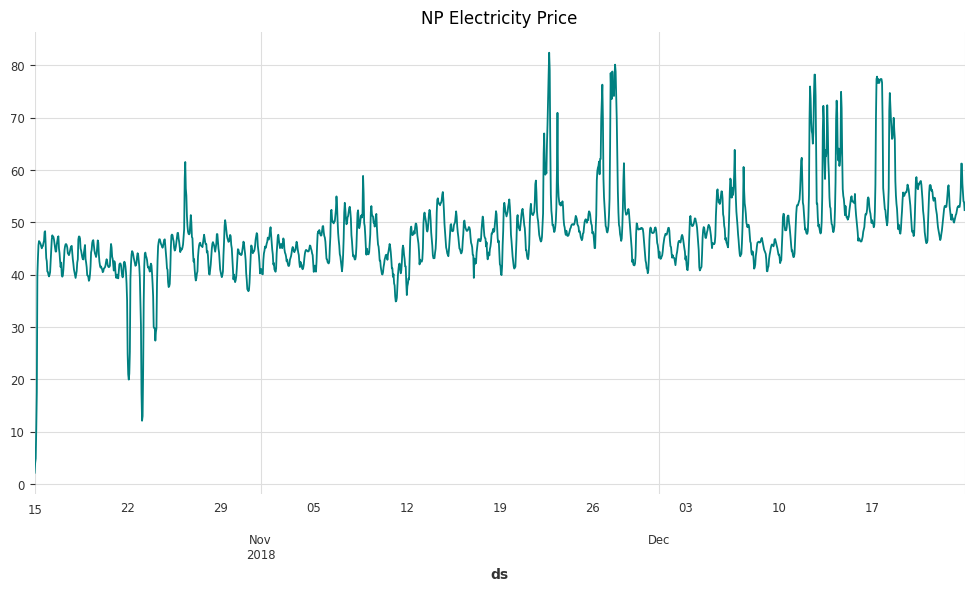

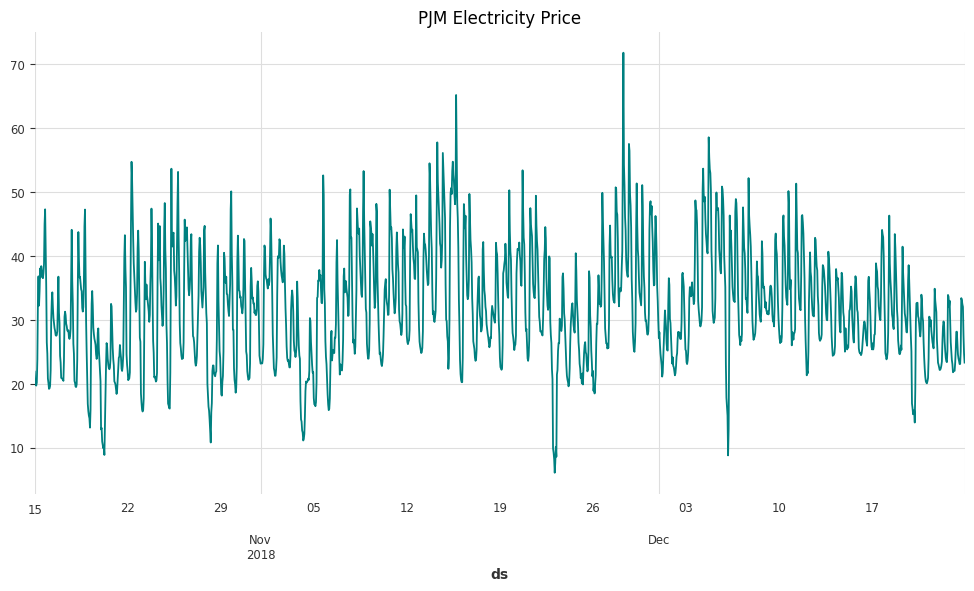

In [ ]:
for country in country_list:
  plt.figure(figsize=(12, 6))
  df[df['unique_id'] == country].y.plot(title=f"{country} Electricity Price", color='teal')
  plt.show()

### Let's look at NP & PJM

In [ ]:
df = df[df['unique_id'].isin(country_list)]

country_df_dict = {}
for country in df['unique_id'].unique():
  country_df_dict[country] = df[df['unique_id'] == country]

df_NP = country_df_dict['NP']
df_PJM = country_df_dict['PJM']

### Seasonal Decomposition

In [ ]:
# Seasonal decomposition of 'Electricity Pricing'  (24 hour period, model='additive')

def seasonal_decomposition(df):
  result = seasonal_decompose(df.y,model='additive', period=24)
  fig = result.plot()
  fig.set_figheight(8)
  fig.set_figwidth(12)
  plt.show()
  return

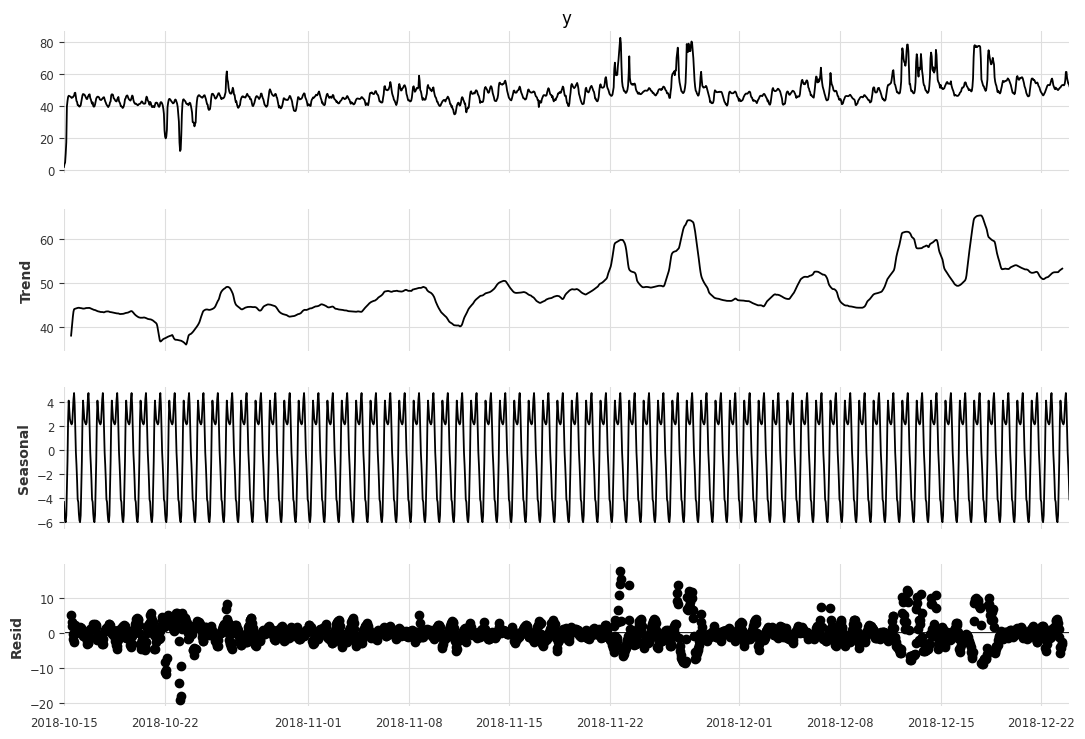

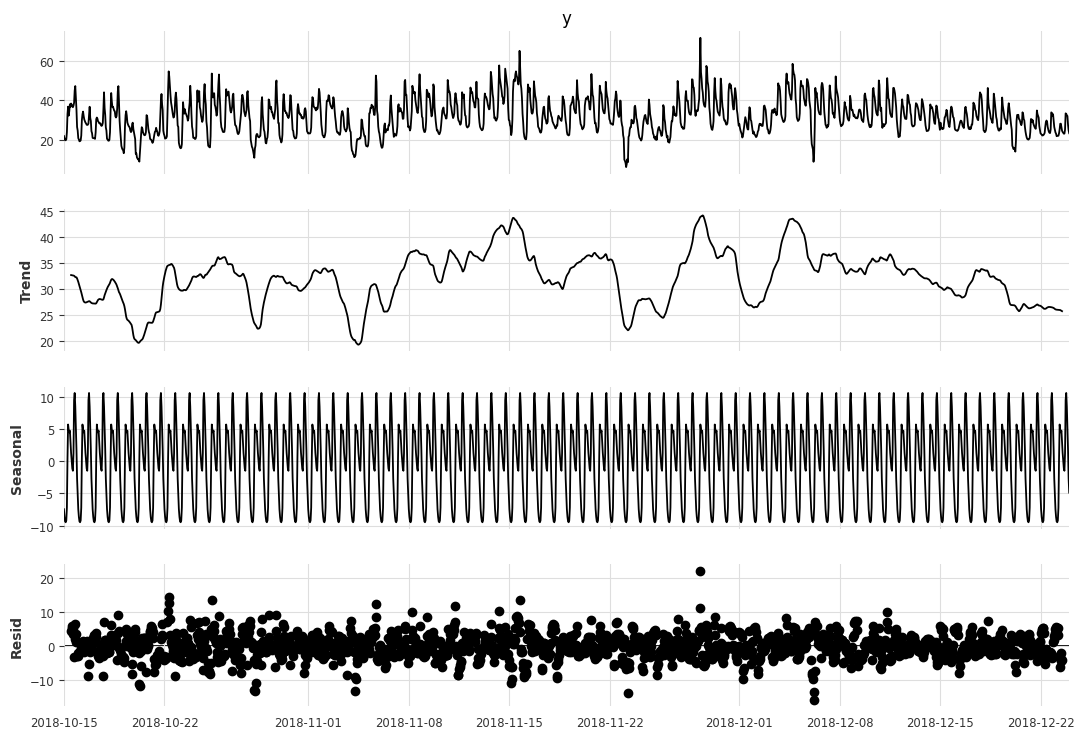

In [ ]:
seasonal_decomposition(df_NP)
seasonal_decomposition(df_PJM)

### ACF and PACF

In [ ]:
def acf_pacf(df,country):
  # Plot the ACF for the electricity pricing data
  fig, ax = plt.subplots(figsize=(15,7))
  plot_acf(df['y'], lags=100, ax=ax, color='teal')
  plt.title(f'ACF of {country} Electricity Pricing')
  plt.show()

  fig, ax = plt.subplots(figsize=(15,7))
  plot_pacf(df['y'], lags=100, ax=ax, color='teal')
  plt.title(f'PACF of {country} Electricity Pricing')
  plt.show()
  return

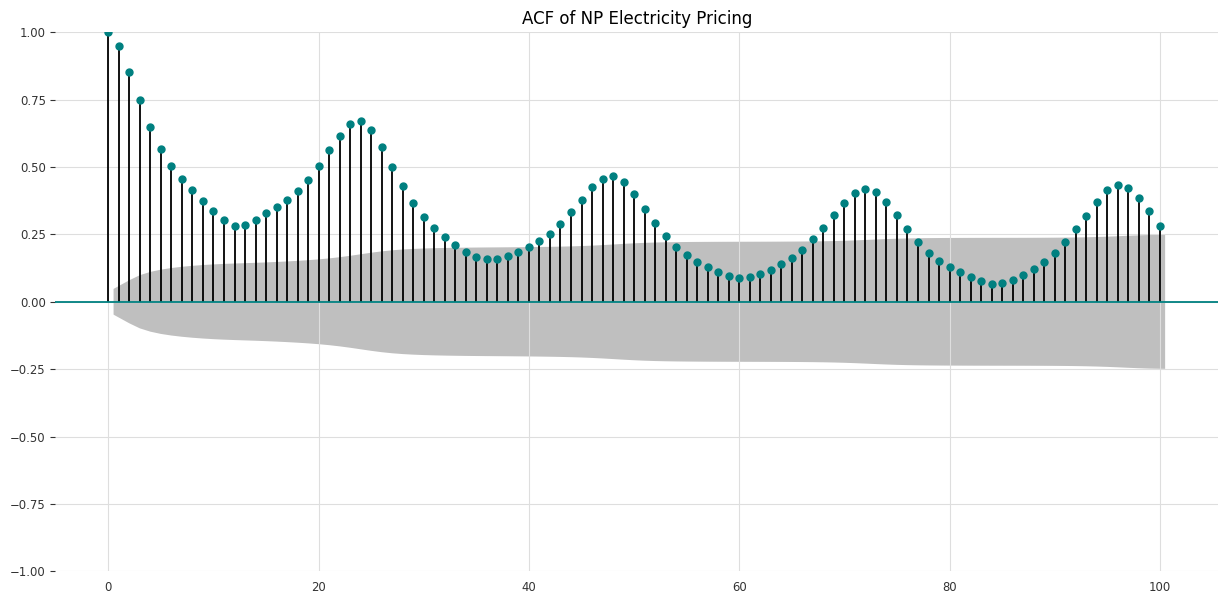

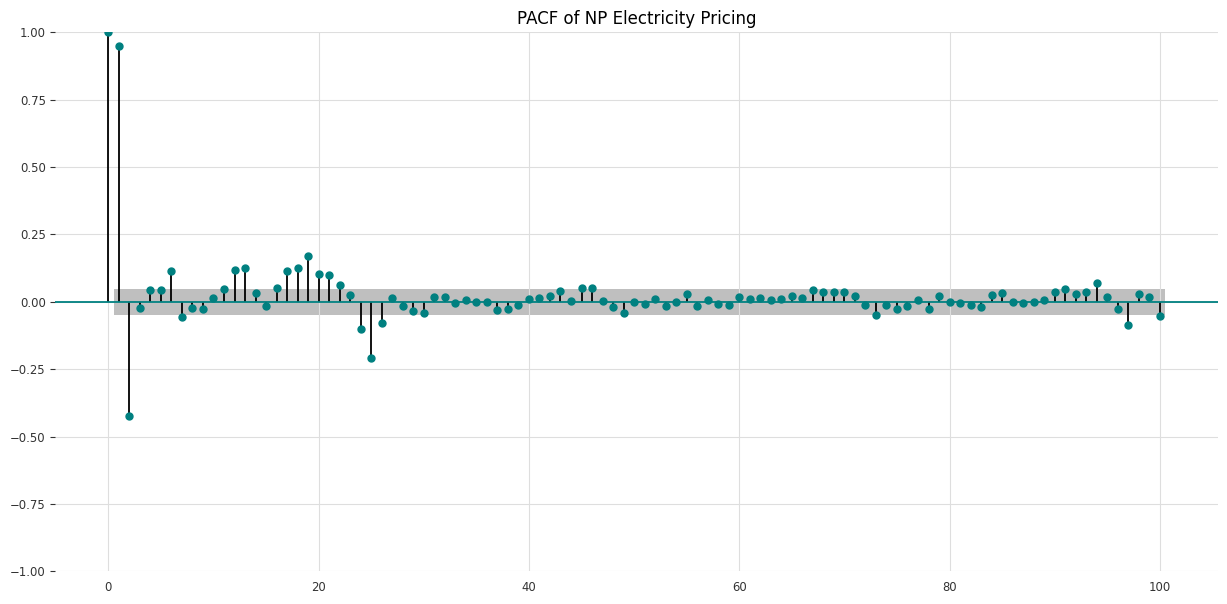

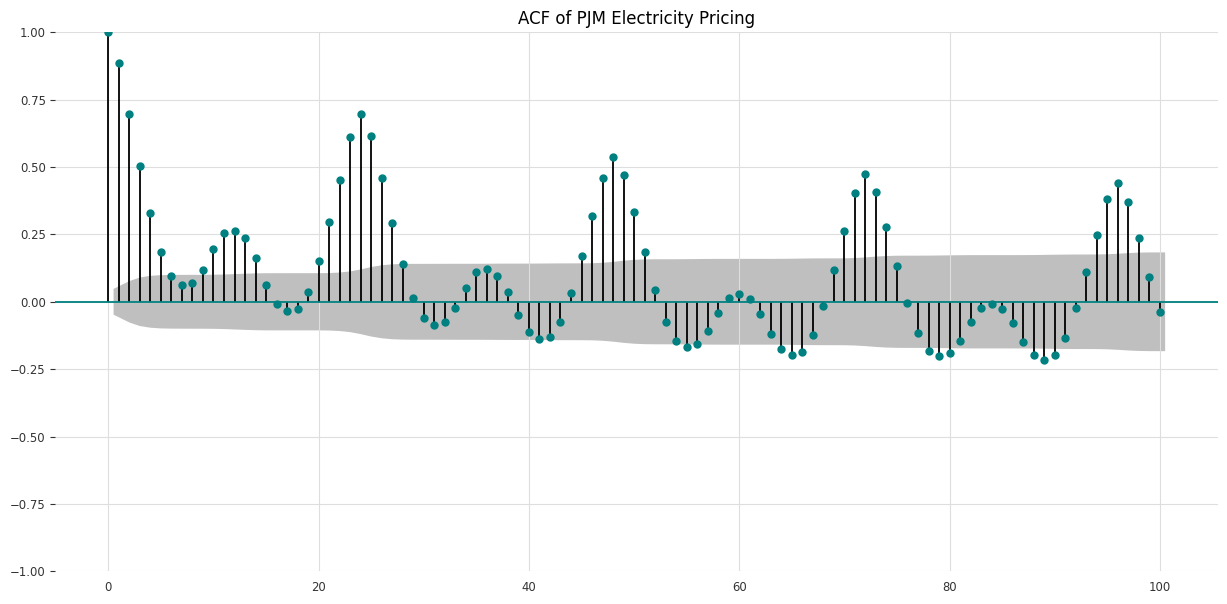

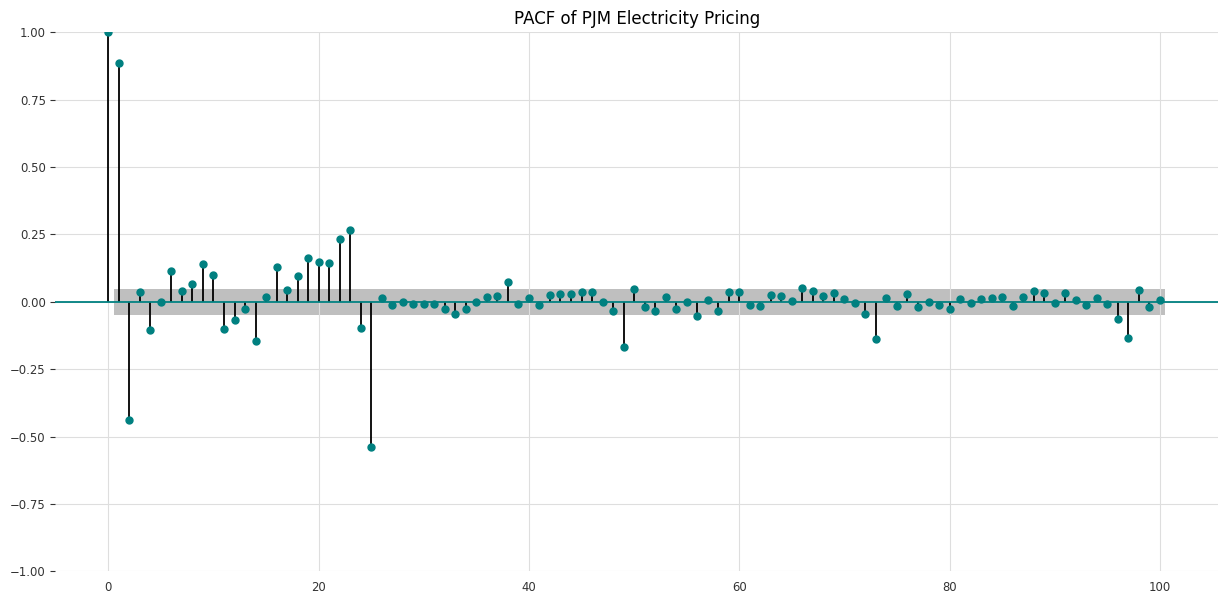

In [ ]:
acf_pacf(df_NP, 'NP')
acf_pacf(df_PJM, 'PJM')

### Let's look at Stationarity

In [ ]:
def adf_test(series, title=None):

  # Run the ADF test
  result = adfuller(series.dropna(), autolag='AIC')

  # Extract and print results
  print('ADF Statistic:', result[0])
  print('p-value:', result[1])
  print('Critical Values:')
  for key, value in result[4].items():
      print(f'   {key}: {value}')

  # Interpretation
  if result[1] < 0.05:
      print("Result: The series is likely stationary (reject H0).")
  else:
      print("Result: The series is likely non-stationary (fail to reject H0).")

In [ ]:
adf_test(df_NP['y'], title='NP Electricity Pricing')
print('\n')
adf_test(df_PJM['y'], title='PJM Electricity Pricing')

ADF Statistic: -3.3554913300195155
p-value: 0.012573042885150012
Critical Values:
   1%: -3.4343097809950986
   5%: -2.8632890172254655
   10%: -2.5677011356149544
Result: The series is likely stationary (reject H0).


ADF Statistic: -4.642934131061114
p-value: 0.00010757140301597731
Critical Values:
   1%: -3.4343073846517536
   5%: -2.863287959472204
   10%: -2.5677005723752067
Result: The series is likely stationary (reject H0).


In [ ]:
# Make 'ds' a column in df instead of index

df.reset_index(inplace=True)
df['unique_id'] = df['unique_id'].astype('category')
df['unique_id'] = df['unique_id'].cat.codes
df.head()

,ds,unique_id,y,Exogenous1,Exogenous2
0,2018-10-15 00:00:00,0,2.17,34078.0,1791.0
1,2018-10-15 01:00:00,0,4.03,33469.0,1489.0
2,2018-10-15 02:00:00,0,4.88,33313.0,1233.0
3,2018-10-15 03:00:00,0,10.47,33535.0,1035.0
4,2018-10-15 04:00:00,0,17.51,34267.0,854.0


### Prepare the TimeSeries objects

In [ ]:
# Set up the variables for the y time series

TIME_COL = "ds"
TARGET = "y"
GROUP_COL = ["unique_id"]
FREQ = "h" # hourly data

# Create the time series instance from the DataFrame using group-based columns
series = TimeSeries.from_group_dataframe(
    df=df,                # DataFrame containing the data
    time_col=TIME_COL,    # Column representing the time dimension
    group_cols=GROUP_COL, # Column(s) representing the group or series identifier(s)
    value_cols=TARGET,    # Column representing the target variable (the value to forecast)
    freq=FREQ             # Frequency of the data
)

# Display the time series instance
series

[<TimeSeries (ds: 1680, component: 1, sample: 1)> Size: 13kB
 array([[[ 2.17]],
 
        [[ 4.03]],
 
        [[ 4.88]],
 
        ...,
 
        [[53.99]],
 
        [[53.86]],
 
        [[52.32]]])
 Coordinates:
   * ds         (ds) datetime64[ns] 13kB 2018-10-15 ... 2018-12-23T23:00:00
   * component  (component) object 8B 'y'
 Dimensions without coordinates: sample
 Attributes:
     static_covariates:  static_covariates  unique_id\ny                      ...
     hierarchy:          None
     metadata:           None,
 <TimeSeries (ds: 1680, component: 1, sample: 1)> Size: 13kB
 array([[[21.911758]],
 
        [[20.657265]],
 
        [[19.825215]],
 
        ...,
 
        [[27.632347]],
 
        [[24.746053]],
 
        [[23.333499]]])
 Coordinates:
   * ds         (ds) datetime64[ns] 13kB 2018-10-15 ... 2018-12-23T23:00:00
   * component  (component) object 8B 'y'
 Dimensions without coordinates: sample
 Attributes:
     static_covariates:  static_covariates  unique_id\ny     

### Set up the Past Covariates

In [ ]:
COVARIATES = ['Exogenous1', 'Exogenous2']

past_covariates = TimeSeries.from_group_dataframe(
    df=df,
    time_col=TIME_COL,
    group_cols=GROUP_COL,
    value_cols=COVARIATES,
    freq=FREQ
    )

past_covariates

[<TimeSeries (ds: 1680, component: 2, sample: 1)> Size: 27kB
 array([[[34078.],
         [ 1791.]],
 
        [[33469.],
         [ 1489.]],
 
        [[33313.],
         [ 1233.]],
 
        ...,
 
        [[55990.],
         [  478.]],
 
        [[54336.],
         [  410.]],
 
        [[51679.],
         [  371.]]])
 Coordinates:
   * ds         (ds) datetime64[ns] 13kB 2018-10-15 ... 2018-12-23T23:00:00
   * component  (component) object 16B 'Exogenous1' 'Exogenous2'
 Dimensions without coordinates: sample
 Attributes:
     static_covariates:  static_covariates  unique_id\nglobal_components      ...
     hierarchy:          None
     metadata:           None,
 <TimeSeries (ds: 1680, component: 2, sample: 1)> Size: 27kB
 array([[[66998.],
         [ 8704.]],
 
        [[65025.],
         [ 8438.]],
 
        [[64091.],
         [ 8283.]],
 
        ...,
 
        [[94319.],
         [11433.]],
 
        [[90106.],
         [11108.]],
 
        [[85547.],
         [10581.]]])
 Coordi

### Create Future Covariates Time Series Object

In [ ]:
df_future = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Time Series Analysis/Python - Time Series Forecasting/Advanced Content for Time Series /FINAL PROJECT - Build an Automated Forecasting Pipeline/electricity-future.csv',
                 index_col='ds',parse_dates=True)
df_future.head()

,unique_id,Exogenous1,Exogenous2
ds,,,
2016-12-31 00:00:00,BE,64108.0,70318.0
2016-12-31 01:00:00,BE,62492.0,67898.0
2016-12-31 02:00:00,BE,61571.0,68379.0
2016-12-31 03:00:00,BE,60381.0,64972.0
2016-12-31 04:00:00,BE,60298.0,62900.0


In [ ]:
df_future.reset_index(inplace=True)
df_future = df_future[df_future['unique_id'].isin(country_list)]
df_future['unique_id'] = df_future['unique_id'].astype('category')
df_future['unique_id'] = df_future['unique_id'].cat.codes
df_future.head()

,ds,unique_id,Exogenous1,Exogenous2
72,2018-12-24 00:00:00,0,49119.0,461.0
73,2018-12-24 01:00:00,0,48115.0,484.0
74,2018-12-24 02:00:00,0,47727.0,497.0
75,2018-12-24 03:00:00,0,47673.0,509.0
76,2018-12-24 04:00:00,0,47848.0,510.0


In [ ]:
# Create past_df

df_past = df.drop(columns=['y'])
df_past.head()

,ds,unique_id,Exogenous1,Exogenous2
0,2018-10-15 00:00:00,0,34078.0,1791.0
1,2018-10-15 01:00:00,0,33469.0,1489.0
2,2018-10-15 02:00:00,0,33313.0,1233.0
3,2018-10-15 03:00:00,0,33535.0,1035.0
4,2018-10-15 04:00:00,0,34267.0,854.0


In [ ]:
# Concatenate past_df with future_df

df_full = pd.concat([df_past, df_future])
df_full.head()

,ds,unique_id,Exogenous1,Exogenous2
0,2018-10-15 00:00:00,0,34078.0,1791.0
1,2018-10-15 01:00:00,0,33469.0,1489.0
2,2018-10-15 02:00:00,0,33313.0,1233.0
3,2018-10-15 03:00:00,0,33535.0,1035.0
4,2018-10-15 04:00:00,0,34267.0,854.0


In [ ]:
# Create the future covariates time series instance from the full DataFrame using group-based columns

future_covariates = TimeSeries.from_group_dataframe(
    df=df_full,           # Full DataFrame containing both current and future data
    time_col=TIME_COL,    # Column representing the time dimension
    group_cols=GROUP_COL, # Column(s) representing the group or series identifier(s)
    value_cols=COVARIATES, # Columns representing the exogenous variables (future covariates)
    freq=FREQ             # Frequency of the data
)

# Display the future covariates time series instance
future_covariates

[<TimeSeries (ds: 1704, component: 2, sample: 1)> Size: 27kB
 array([[[34078.],
         [ 1791.]],
 
        [[33469.],
         [ 1489.]],
 
        [[33313.],
         [ 1233.]],
 
        ...,
 
        [[51488.],
         [ 2919.]],
 
        [[50928.],
         [ 3119.]],
 
        [[49889.],
         [ 3306.]]])
 Coordinates:
   * ds         (ds) datetime64[ns] 14kB 2018-10-15 ... 2018-12-24T23:00:00
   * component  (component) object 16B 'Exogenous1' 'Exogenous2'
 Dimensions without coordinates: sample
 Attributes:
     static_covariates:  static_covariates  unique_id\nglobal_components      ...
     hierarchy:          None
     metadata:           None,
 <TimeSeries (ds: 1704, component: 2, sample: 1)> Size: 27kB
 array([[[66998.],
         [ 8704.]],
 
        [[65025.],
         [ 8438.]],
 
        [[64091.],
         [ 8283.]],
 
        ...,
 
        [[92923.],
         [10963.]],
 
        [[90970.],
         [10802.]],
 
        [[88037.],
         [10419.]]])
 Coordi

### Scaling

In [ ]:
scaler1 = Scaler()
scaler2 = Scaler()

y_transformed = scaler1.fit_transform(series)
past_covariates_transformed = scaler2.fit_transform(past_covariates)
future_covariates_transformed = scaler2.transform(future_covariates)